In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

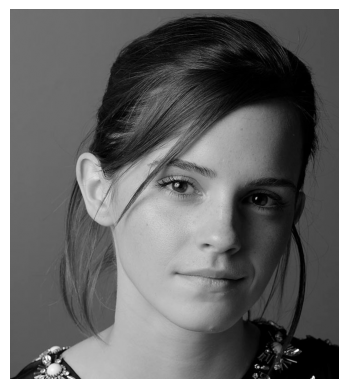

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread("/kaggle/input/datasets/isithadinujaya/cv-images/emma.jpg", cv.IMREAD_GRAYSCALE)

plt.imshow(im, cmap="gray")
plt.axis("off")
plt.show()

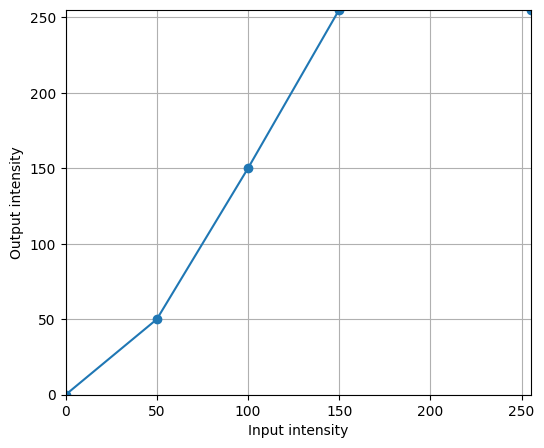

In [5]:
breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
])
def intensity_transform(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    transformed = np.interp(im, x, y)
    return transformed.astype(np.uint8)

im_transformed = intensity_transform(im, breakpoints)

plt.figure(figsize=(6, 5))
plt.plot(breakpoints[:, 0],
         breakpoints[:, 1],
         marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()
plt.show()

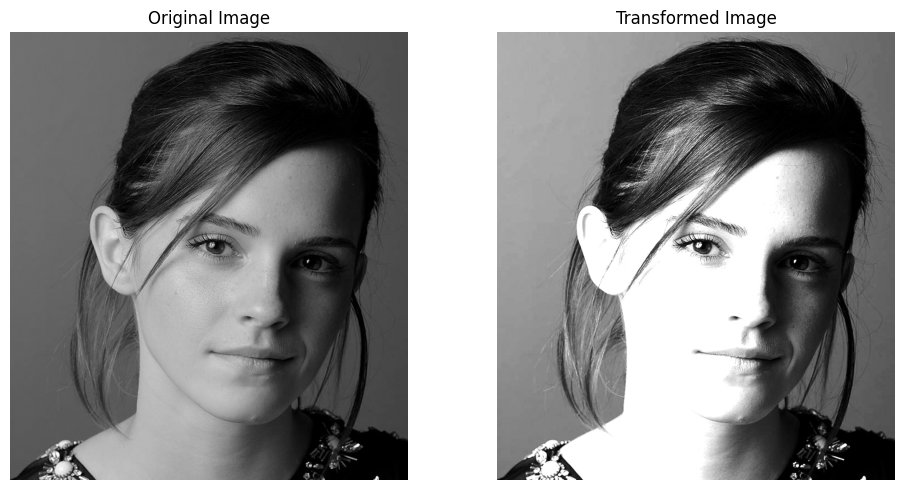

In [6]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(im_transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# # **Question 2**

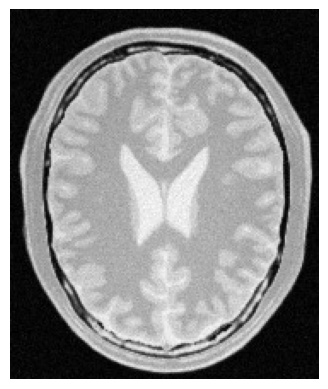

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

brain = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/q2.jpeg", cv.IMREAD_GRAYSCALE)

plt.imshow(brain, cmap="gray")
plt.axis("off")
plt.show()

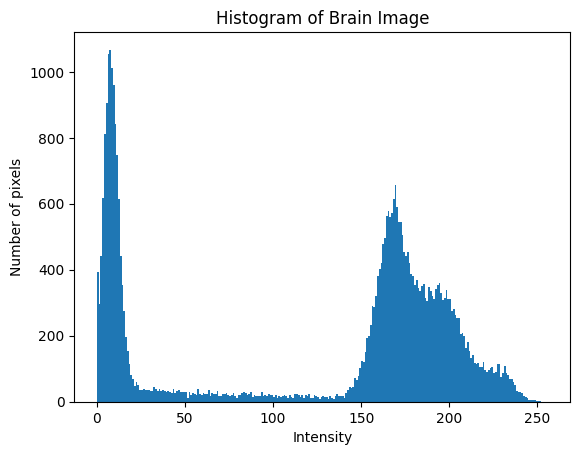

In [8]:
plt.hist(brain.ravel(), bins=256, range=[0, 256])

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Image")
plt.show()

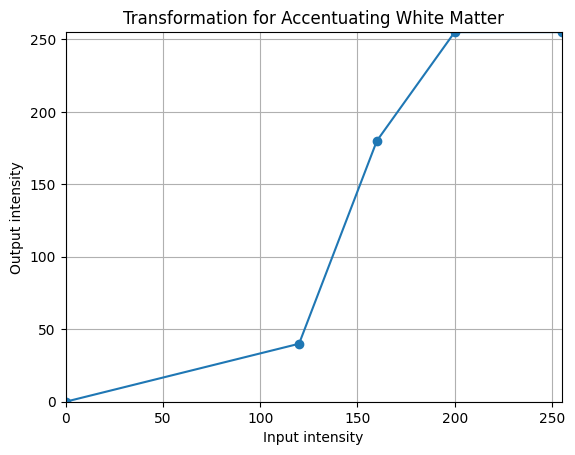

In [9]:
def intensity_transform(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    transformed = np.interp(im, x, y)

    return transformed.astype(np.uint8)

bp_white = np.array([
    [0,   0],
    [120, 40],
    [160, 180],
    [200, 255],
    [255, 255]
])

white_result = intensity_transform(brain, bp_white)

plt.plot(bp_white[:, 0], bp_white[:, 1], marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transformation for Accentuating White Matter")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.show()

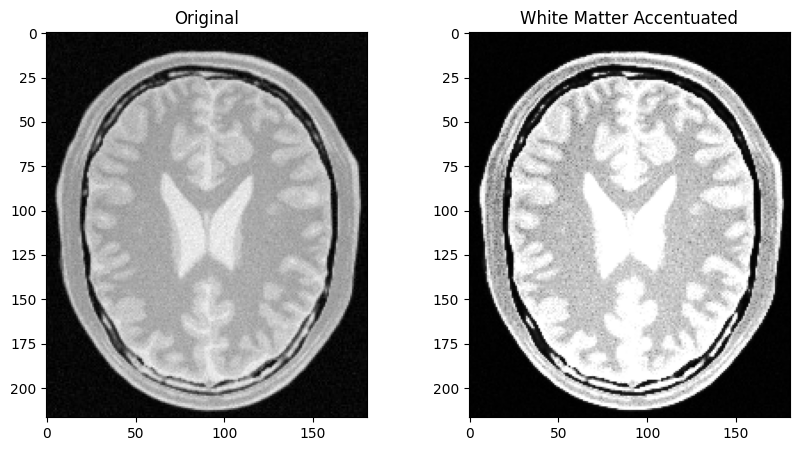

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(white_result, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")

plt.show()

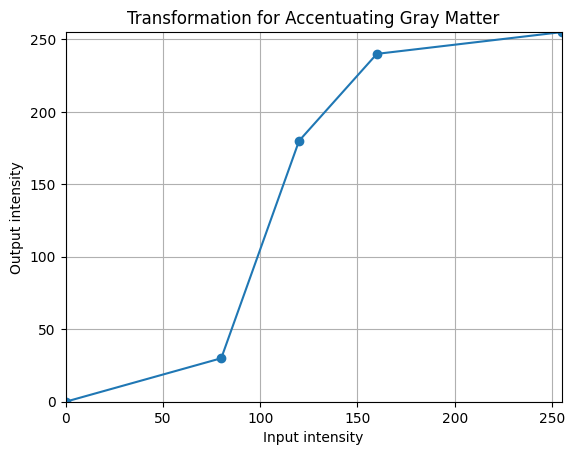

In [11]:
bp_gray = np.array([
    [0,   0],
    [80,  30],
    [120, 180],
    [160, 240],
    [255, 255]
])

gray_result = intensity_transform(brain, bp_gray)

plt.plot(bp_gray[:, 0], bp_gray[:, 1], marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transformation for Accentuating Gray Matter")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

plt.show()

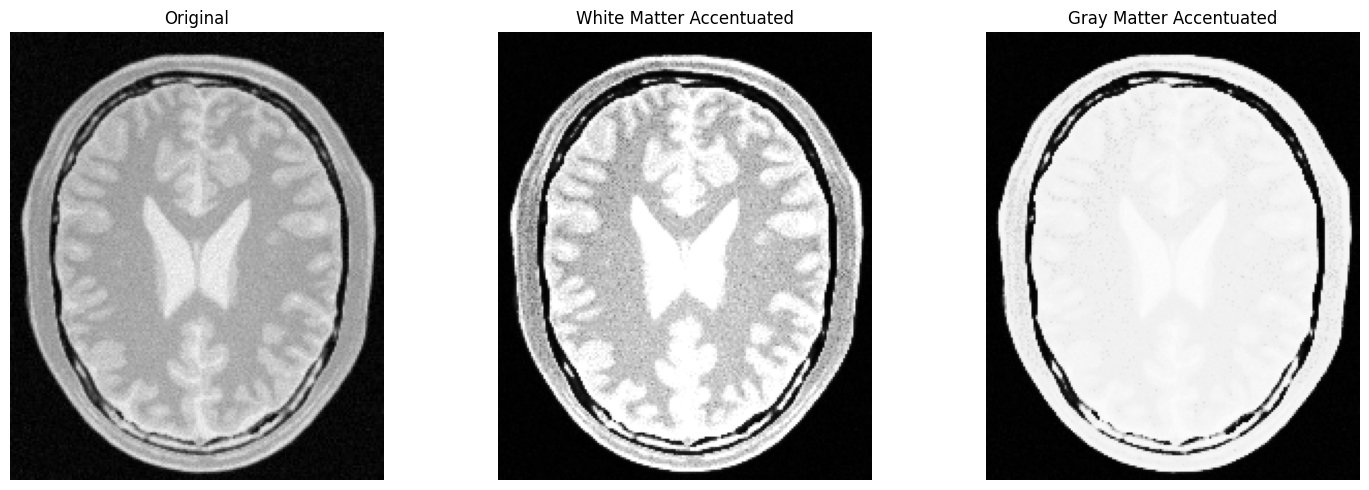

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(brain, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(white_result, cmap="gray", vmin=0, vmax=255)
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_result, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

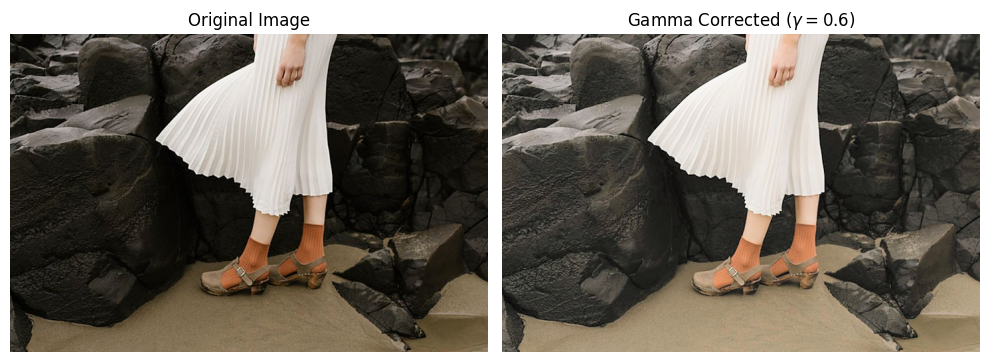

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg")


lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.6

L_corrected = 255 * (L / 255.0) ** gamma
L_corrected = L_corrected.astype(np.uint8)
lab_corrected = cv.merge([L_corrected, a, b])
corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
corrected_rgb = cv.cvtColor(corrected, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected_rgb)
plt.title(f"Gamma Corrected ($\\gamma={gamma}$)")
plt.axis("off")

plt.tight_layout()
plt.show()

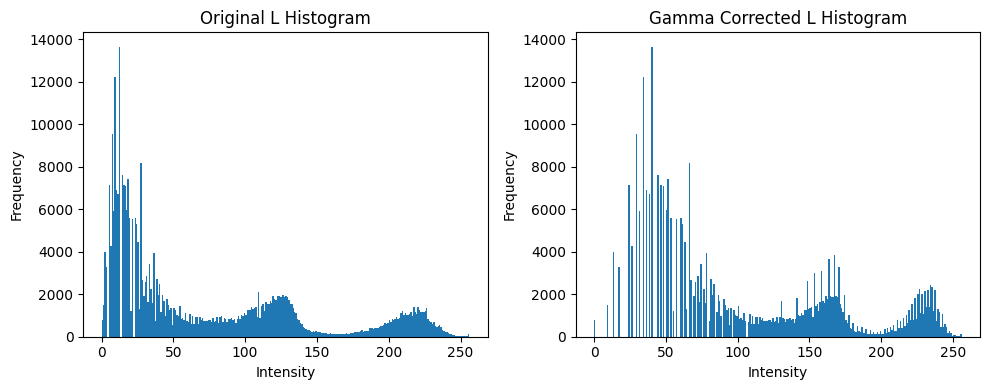

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(L.ravel(), bins=256, range=[0, 256])
plt.title("Original L Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), bins=256, range=[0, 256])
plt.title("Gamma Corrected L Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## **Question 04** 

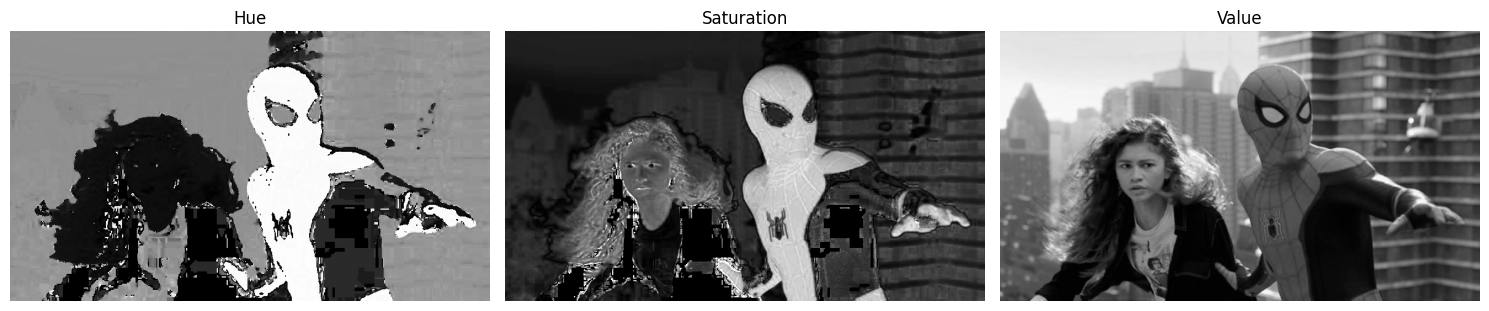

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

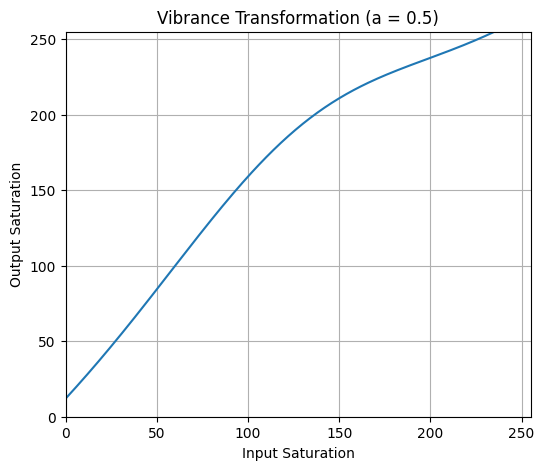

In [3]:
def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float32)

    y = x + a * 128 * np.exp(
        -((x - 128) ** 2) / (2 * sigma ** 2)
    )

    return np.minimum(y, 255).astype(np.uint8)

a = 0.5
S_new = vibrance_transform(S, a)

hsv_new = cv.merge([H, S_new, V])
enhanced = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
enhanced_rgb = cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)

x = np.arange(256)

a = 0.5
sigma = 70

y = x + a * 128 * np.exp(
    -((x - 128) ** 2) / (2 * sigma ** 2)
)

y = np.minimum(y, 255)

plt.figure(figsize=(6, 5))
plt.plot(x, y)

plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(f"Vibrance Transformation (a = {a})")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.show()

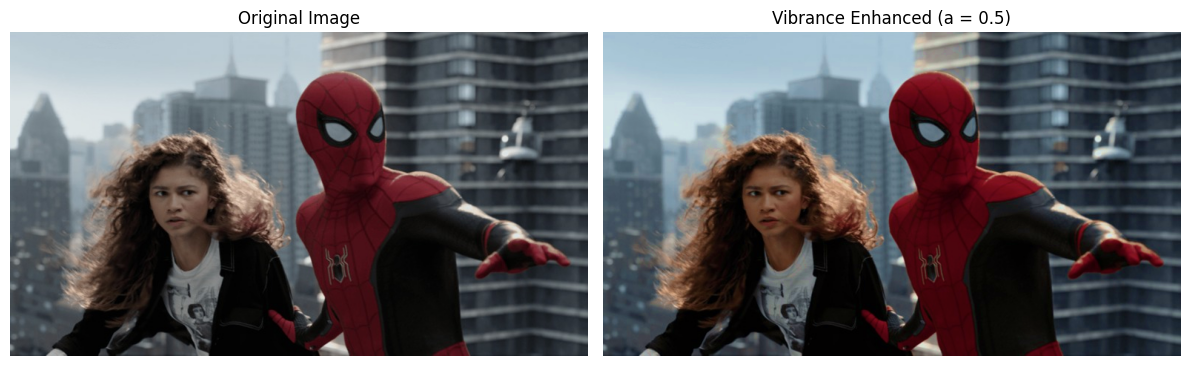

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced (a = {a})")
plt.axis("off")

plt.tight_layout()
plt.show()

# # **Question 5**

[ WARN:0@260.578] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


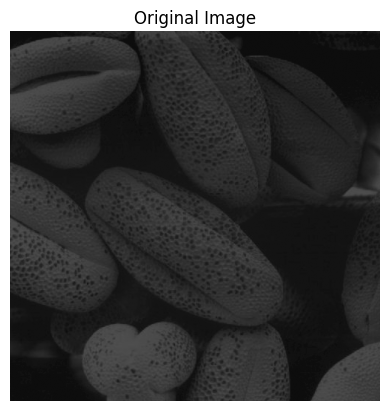

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/shells.tif", cv.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")
plt.show()

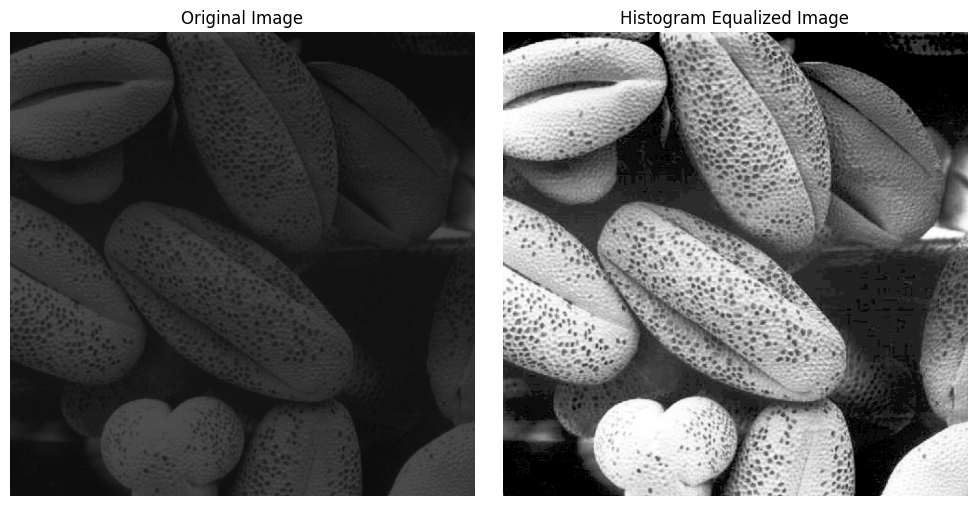

In [8]:
def histogram_equalization(img):

    # Calculate histogram
    hist = np.bincount(img.ravel(), minlength=256)

    # Calculate cumulative histogram
    cdf = np.cumsum(hist)

    # Find the first non-zero CDF value
    cdf_min = cdf[cdf > 0][0]

    # Total number of pixels
    N = img.size

    # Create transformation
    T = np.round(
        255 * (cdf - cdf_min) / (N - cdf_min)
    )

    # Keep values within 0-255
    T = np.clip(T, 0, 255).astype(np.uint8)

    # Apply transformation to every pixel
    equalized = T[img]

    return equalized

equalized = histogram_equalization(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

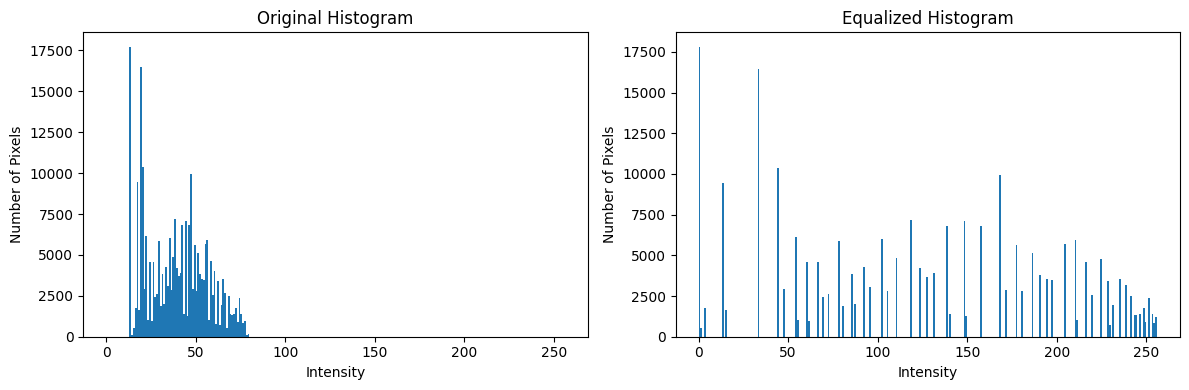

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(), bins=256, range=[0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

# # **Question 06**

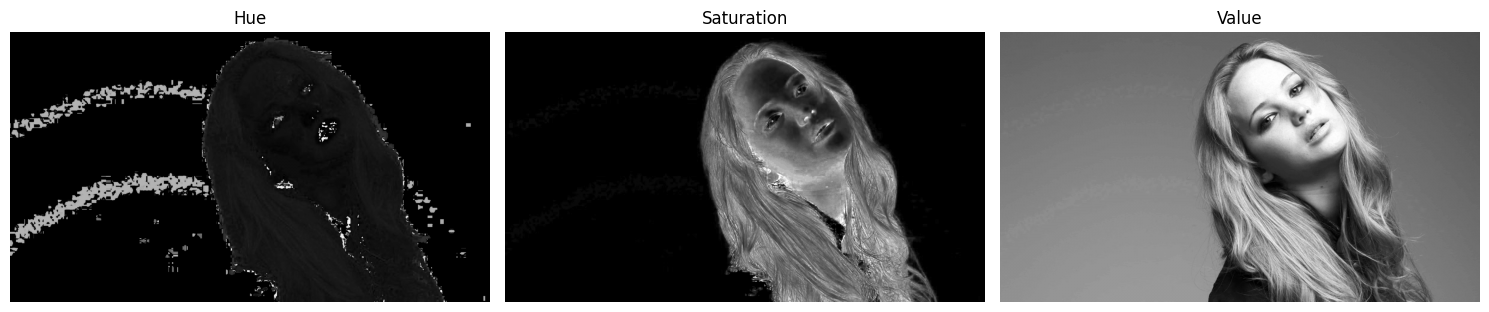

In [10]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(hsv)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

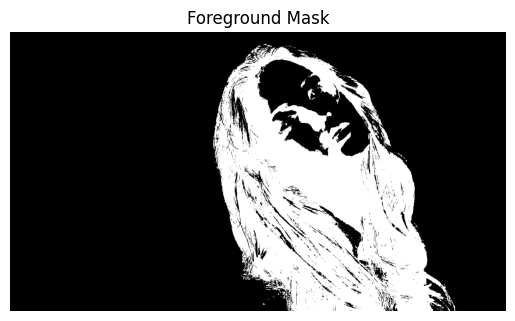

In [11]:
_, mask = cv.threshold(S, 80, 255, cv.THRESH_BINARY)

plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")
plt.show()

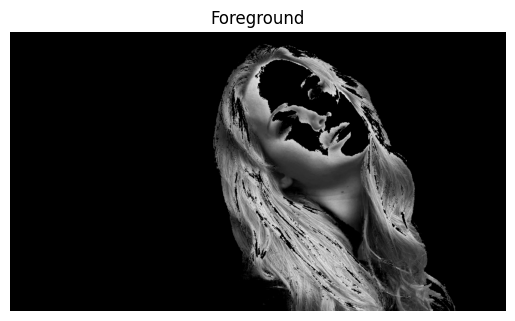

In [12]:
foreground = cv.bitwise_and(V, V, mask=mask)

plt.imshow(foreground, cmap="gray")
plt.title("Foreground")
plt.axis("off")
plt.show()

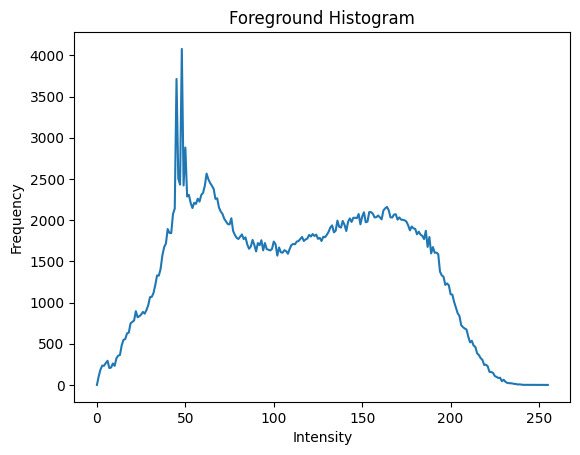

In [13]:
foreground_pixels = V[mask > 0]

hist = np.bincount(
    foreground_pixels.ravel(),
    minlength=256
)

plt.plot(hist)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.title("Foreground Histogram")
plt.show()

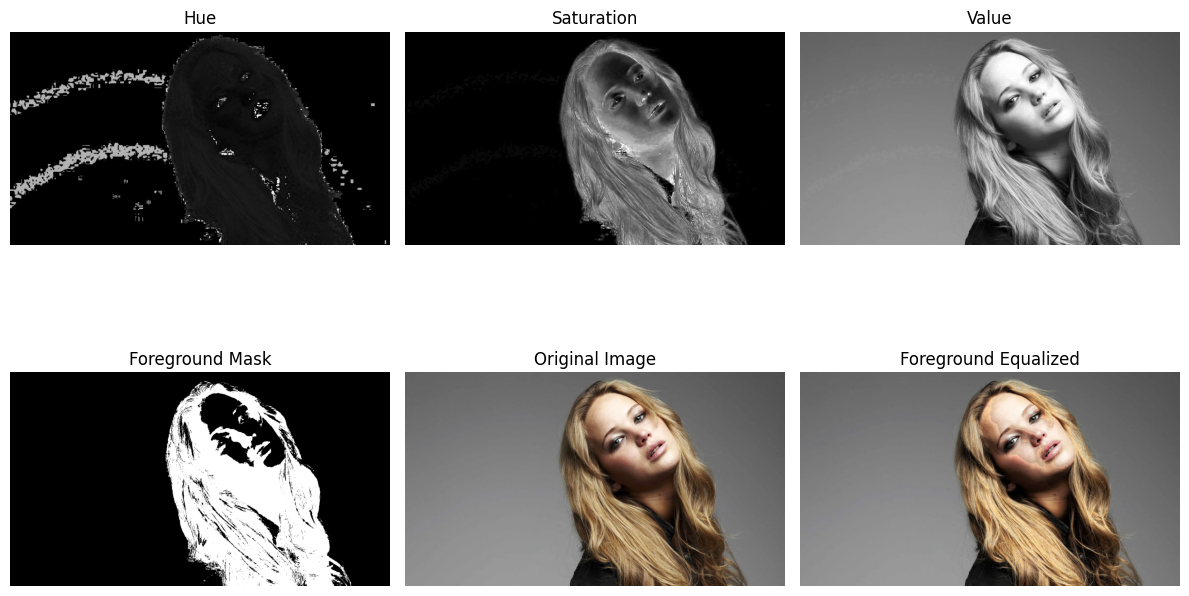

In [16]:
cdf = np.cumsum(hist)
cdf_min = cdf[cdf > 0][0]
N = foreground_pixels.size

T = np.round(
    255 * (cdf - cdf_min) / (N - cdf_min)
)

T = np.clip(T, 0, 255).astype(np.uint8)

V_equalized = V.copy()
V_equalized[mask > 0] = T[V[mask > 0]]

hsv_equalized = cv.merge([H, S, V_equalized])

result = cv.cvtColor(
    hsv_equalized,
    cv.COLOR_HSV2BGR
)

original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(result_rgb)
plt.title("Foreground Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()

# **Question 07**

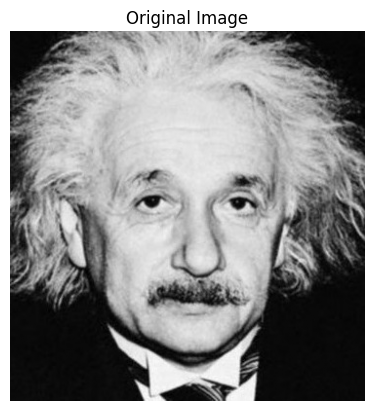

In [17]:
img = cv.imread("/kaggle/input/datasets/isithadinujaya/vision-data-set/images/WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg", cv.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

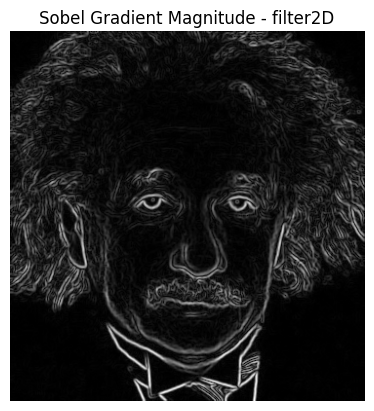

In [21]:
Gx = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

Gy = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

sobel_x = cv.filter2D(img.astype(np.float32), -1, Gx)
sobel_y = cv.filter2D(img.astype(np.float32), -1, Gy)

magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

magnitude_display = cv.normalize(
    magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)

plt.imshow(magnitude_display, cmap="gray")
plt.title("Sobel Gradient Magnitude - filter2D")
plt.axis("off")
plt.show()

In [25]:
def my_filter2d(img, kernel):
    img = img.astype(np.float32)

    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        img,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant"
    )

    output = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            region = padded[
                i:i+kh,
                j:j+kw
            ]

            output[i, j] = np.sum(region * kernel)

    return output

my_sobel_x = my_filter2d(img, Gx)
my_sobel_y = my_filter2d(img, Gy)

my_magnitude = np.sqrt(
    my_sobel_x**2 + my_sobel_y**2
)

my_magnitude_display = cv.normalize(
    my_magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)

my_magnitude_display = cv.normalize(
    my_magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)


smooth_col = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

diff_row = np.array([
    [1, 0, -1]
], dtype=np.float32)

temp_x = cv.filter2D(
    img.astype(np.float32),
    -1,
    smooth_col
)

sep_sobel_x = cv.filter2D(
    temp_x,
    -1,
    diff_row
)

smooth_row = np.array([
    [1, 2, 1]
], dtype=np.float32)

diff_col = np.array([
    [ 1],
    [ 0],
    [-1]
], dtype=np.float32)

temp_y = cv.filter2D(
    img.astype(np.float32),
    -1,
    smooth_row
)

sep_sobel_y = cv.filter2D(
    temp_y,
    -1,
    diff_col
)


sep_magnitude = np.sqrt(
    sep_sobel_x**2 + sep_sobel_y**2
)

sep_magnitude_display = cv.normalize(
    sep_magnitude,
    None,
    0,
    255,
    cv.NORM_MINMAX
).astype(np.uint8)

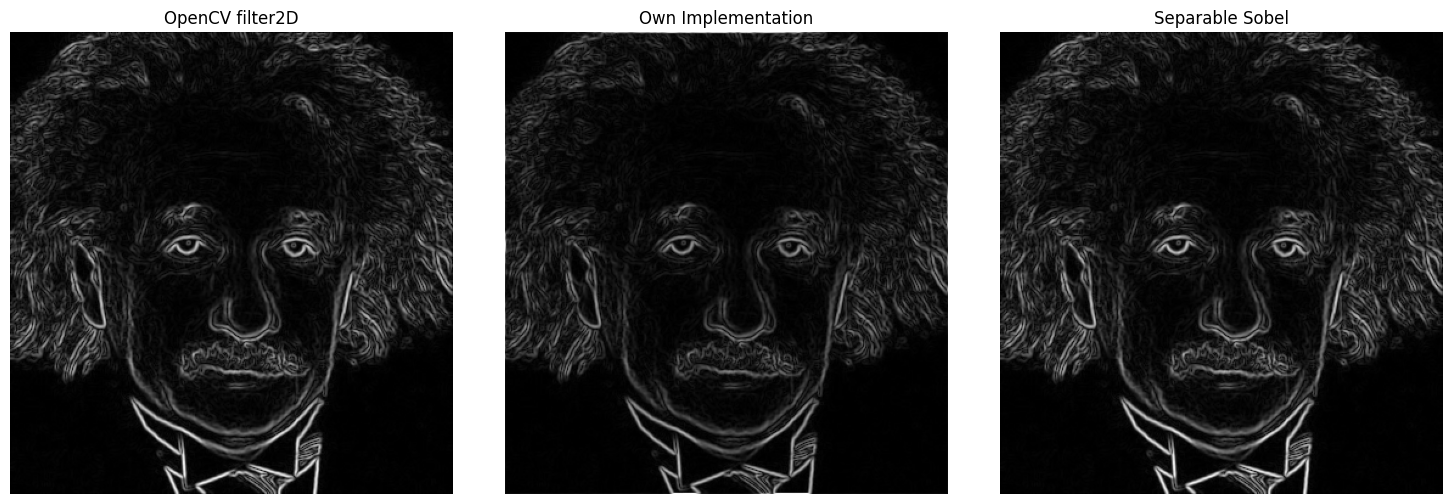

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_display, cmap="gray")
plt.title("OpenCV filter2D")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(my_magnitude_display, cmap="gray")
plt.title("Own Implementation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sep_magnitude_display, cmap="gray")
plt.title("Separable Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()